# Business Understanding

# Data Acquisition and Understanding

## DSO1

## DSO2

## DSO3

## DSO4

### Data collection

In [11]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# 1. Charger les données
df_hourly = pd.read_csv('saleshourly.csv')
df_daily = pd.read_csv('salesdaily.csv')
df_weekly = pd.read_csv('salesweekly.csv')
df_monthly = pd.read_csv('salesmonthly.csv')

# Afficher un aperçu pour vérifier
print("--- Données Horaires ---")
print(df_hourly.head())
print(df_hourly.info())
print("\n--- Données Quotidiennes ---")
print(df_daily.head())
print(df_daily.info())
print("\n--- Données Hebdomadaires ---")
print(df_weekly.head())
print(df_weekly.info())
print("\n--- Données Mensuelles ---")
print(df_monthly.head())
print(df_monthly.info())

# 2. Créer une colonne 'year_month' pour chaque DataFrame
# ========================================================

# Pour df_hourly
df_hourly['date'] = pd.to_datetime(df_hourly['datum'])
df_hourly['year_month'] = df_hourly['date'].dt.to_period('M')

# Pour df_daily
df_daily['date'] = pd.to_datetime(df_daily['datum'])
df_daily['year_month'] = df_daily['date'].dt.to_period('M')

# Pour df_weekly
df_weekly['date'] = pd.to_datetime(df_weekly['datum'])
df_weekly['year_month'] = df_weekly['date'].dt.to_period('M')

# Pour df_monthly
df_monthly['date'] = pd.to_datetime(df_monthly['datum'])
df_monthly['year_month'] = df_monthly['date'].dt.to_period('M')

print("\n✅ Colonnes 'year_month' créées pour tous les DataFrames")

# 3. Agrégation mensuelle de chaque source
# ========================================

print("\n--- Agrégation mensuelle des données ---")

# Agrégation des données horaires
df_hourly_monthly = df_hourly.groupby('year_month').agg({
    'M01AB': 'sum',
    'M01AE': 'sum',
    'N02BA': 'sum',
    'N02BE': 'sum',
    'N05B': 'sum',
    'N05C': 'sum',
    'R03': 'sum',
    'R06': 'sum'
}).reset_index()
print(f"✓ Données horaires agrégées: {len(df_hourly_monthly)} mois")

# Agrégation des données quotidiennes
df_daily_monthly = df_daily.groupby('year_month').agg({
    'M01AB': 'sum',
    'M01AE': 'sum',
    'N02BA': 'sum',
    'N02BE': 'sum',
    'N05B': 'sum',
    'N05C': 'sum',
    'R03': 'sum',
    'R06': 'sum'
}).reset_index()
print(f"✓ Données quotidiennes agrégées: {len(df_daily_monthly)} mois")

# Les données hebdomadaires sont déjà mensuelles dans le fichier original
# Mais on va les regrouper par mois pour être sûr
df_weekly_monthly = df_weekly.groupby('year_month').agg({
    'M01AB': 'sum',
    'M01AE': 'sum',
    'N02BA': 'sum',
    'N02BE': 'sum',
    'N05B': 'sum',
    'N05C': 'sum',
    'R03': 'sum',
    'R06': 'sum'
}).reset_index()
print(f"✓ Données hebdomadaires agrégées: {len(df_weekly_monthly)} mois")

# Les données mensuelles sont déjà prêtes
df_monthly_clean = df_monthly[['year_month', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']].copy()
print(f"✓ Données mensuelles: {len(df_monthly_clean)} mois")

# 4. Fusionner toutes les données mensuelles
# ==========================================

print("\n--- Fusion des données mensuelles ---")

# Créer un DataFrame avec tous les mois uniques de toutes les sources
all_months = pd.concat([
    df_hourly_monthly['year_month'],
    df_daily_monthly['year_month'],
    df_weekly_monthly['year_month'],
    df_monthly_clean['year_month']
]).unique()
all_months = pd.Series(sorted(all_months)).reset_index(drop=True)
df_final_monthly = pd.DataFrame({'year_month': all_months})
print(f"✓ Période couverte: {len(df_final_monthly)} mois uniques")

# Fonction pour fusionner avec priorité
def merge_with_priority(df_base, df_new, priority_name):
    """Fusionne df_new dans df_base avec un suffixe pour traçabilité"""
    return df_base.merge(
        df_new, 
        on='year_month', 
        how='left', 
        suffixes=('', f'_{priority_name}')
    )

# Fusionner étape par étape avec priorité décroissante
# Priorité 1: Données mensuelles (source la plus fiable pour le mois)
df_final_monthly = merge_with_priority(df_final_monthly, df_monthly_clean, 'monthly')

# Priorité 2: Données hebdomadaires agrégées
df_final_monthly = merge_with_priority(df_final_monthly, df_weekly_monthly, 'weekly')

# Priorité 3: Données quotidiennes agrégées
df_final_monthly = merge_with_priority(df_final_monthly, df_daily_monthly, 'daily')

# Priorité 4: Données horaires agrégées
df_final_monthly = merge_with_priority(df_final_monthly, df_hourly_monthly, 'hourly')

# Maintenant, pour chaque colonne de médicament, on prend la première valeur non-nulle
# dans l'ordre de priorité
for col in ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']:
    # Créer une liste des colonnes par ordre de priorité
    priority_cols = [
        f'{col}_monthly',
        f'{col}_weekly',
        f'{col}_daily',
        f'{col}_hourly'
    ]
    
    # Initialiser avec des NaN
    df_final_monthly[col] = np.nan
    
    # Remplir dans l'ordre de priorité
    for pcol in priority_cols:
        if pcol in df_final_monthly.columns:
            df_final_monthly[col] = df_final_monthly[col].fillna(df_final_monthly[pcol])
            df_final_monthly.drop(columns=[pcol], inplace=True)
    
    # Arrondir à 2 décimales pour plus de lisibilité
    df_final_monthly[col] = df_final_monthly[col].round(2)

print("✓ Fusion terminée avec priorité: mensuel > hebdo > quotidien > horaire")

# 5. Ajouter des colonnes temporelles pour l'analyse
# ==================================================

df_final_monthly['year'] = df_final_monthly['year_month'].dt.year
df_final_monthly['month'] = df_final_monthly['year_month'].dt.month
df_final_monthly['quarter'] = df_final_monthly['year_month'].dt.quarter

# Créer une colonne date pour faciliter le tri et la visualisation
df_final_monthly['date'] = df_final_monthly['year_month'].dt.to_timestamp()

print("✓ Colonnes temporelles ajoutées")

# 6. Calculer le total des ventes par mois
# ========================================

sales_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
df_final_monthly['total_sales'] = df_final_monthly[sales_columns].sum(axis=1).round(2)

print("✓ Total des ventes calculé")

# 7. Trier par date
# =================

df_final_monthly = df_final_monthly.sort_values('date').reset_index(drop=True)

# 8. Afficher un aperçu final
# ===========================

print("\n--- Aperçu du DataFrame mensuel final ---")
print(f"Dimensions: {df_final_monthly.shape[0]} lignes, {df_final_monthly.shape[1]} colonnes")
print(f"Période: {df_final_monthly['date'].min().date()} à {df_final_monthly['date'].max().date()}")
print("\nPremières lignes:")
print(df_final_monthly.head(12).to_string())  # Afficher une année complète

print("\nDernières lignes:")
print(df_final_monthly.tail(12).to_string())

print("\nStatistiques descriptives:")
print(df_final_monthly[sales_columns + ['total_sales']].describe().round(2))

# 9. Sauvegarder le résultat
# ==========================

df_final_monthly.to_excel('hcp_sales_monthly_final.xlsx', index=False)
print("\n✅ Fichier 'hcp_sales_monthly_final.xlsx' créé avec succès !")

# 10. Vérification rapide de la qualité
# ======================================

print("\n--- Vérification rapide de la qualité ---")
print(f"Valeurs manquantes: {df_final_monthly[sales_columns].isnull().sum().sum()}")
print(f"Doublons de mois: {df_final_monthly['year_month'].duplicated().sum()}")

# Vérifier la continuité des mois
all_months_expected = pd.period_range(
    start=df_final_monthly['year_month'].min(), 
    end=df_final_monthly['year_month'].max(), 
    freq='M'
)
missing_months = set(all_months_expected) - set(df_final_monthly['year_month'])
if missing_months:
    print(f"⚠️ Mois manquants: {sorted([str(m) for m in missing_months])}")
else:
    print("✅ Série mensuelle complète")

print("\n" + "="*60)
print("ANALYSE TERMINÉE - FICHIER MENSUEL PRÊT")
print("="*60)

--- Données Horaires ---
            datum  M01AB  M01AE  N02BA  N02BE  N05B  N05C  R03  R06  Year  \
0   1/2/2014 8:00    0.0   0.67    0.4    2.0   0.0   0.0  0.0  1.0  2014   
1   1/2/2014 9:00    0.0   0.00    1.0    0.0   2.0   0.0  0.0  0.0  2014   
2  1/2/2014 10:00    0.0   0.00    0.0    3.0   2.0   0.0  0.0  0.0  2014   
3  1/2/2014 11:00    0.0   0.00    0.0    2.0   1.0   0.0  0.0  0.0  2014   
4  1/2/2014 12:00    0.0   2.00    0.0    5.0   2.0   0.0  0.0  0.0  2014   

   Month  Hour Weekday Name  
0      1     8     Thursday  
1      1     9     Thursday  
2      1    10     Thursday  
3      1    11     Thursday  
4      1    12     Thursday  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50532 entries, 0 to 50531
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   datum         50532 non-null  object 
 1   M01AB         50532 non-null  float64
 2   M01AE         50532 non-null  float64
 3   N02

### Data augmentation

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("DATA AUGMENTATION - DONNÉES MENSUELLES DE VENTES")
print("="*80)

# 1. CHARGER LES DONNÉES
# ======================
df_original = pd.read_excel('hcp_sales_monthly_final.xlsx')
print(f"\n📊 Données originales: {df_original.shape[0]} mois, {df_original.shape[1]} colonnes")
print(f"Période: {df_original['date'].min()} à {df_original['date'].max()}")

# S'assurer que la colonne date est au bon format
df_original['date'] = pd.to_datetime(df_original['date'])

# Identifier les colonnes de ventes
sales_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

# Supprimer la colonne 'year_month' si elle existe (format string '2014-01')
if 'year_month' in df_original.columns:
    df_original = df_original.drop(columns=['year_month'])

# S'assurer que les colonnes numériques sont bien des float
for col in sales_columns:
    if col in df_original.columns:
        df_original[col] = pd.to_numeric(df_original[col], errors='coerce').fillna(0)

# Recalculer total_sales
df_original['total_sales'] = df_original[sales_columns].sum(axis=1)

print(f"✅ Données préparées: {df_original.shape[0]} lignes, {df_original.shape[1]} colonnes")

# ======================================================================
# MÉTHODE 1: DÉCOMPOSITION PAR PRODUIT (créer des lignes par catégorie)
# ======================================================================
print("\n" + "="*60)
print("MÉTHODE 1: DÉCOMPOSITION PAR CATÉGORIE DE PRODUITS")
print("="*60)

# Regrouper les produits par catégories thérapeutiques
product_categories = {
    'Anti-inflammatoires': ['M01AB', 'M01AE'],
    'Antalgiques': ['N02BA', 'N02BE'],
    'Psychotropes': ['N05B', 'N05C'],
    'Respiratoires': ['R03', 'R06']
}

# Créer un DataFrame avec une ligne par mois ET par catégorie
category_rows = []
for idx, row in df_original.iterrows():
    for category, products in product_categories.items():
        category_sales = sum([row[prod] for prod in products])
        new_row = {
            'date': row['date'],
            'year': int(row['year']) if 'year' in row else row['date'].year,
            'month': int(row['month']) if 'month' in row else row['date'].month,
            'quarter': int(row['quarter']) if 'quarter' in row else (row['date'].month-1)//3 + 1,
            'category': category,
            'sales': float(category_sales),
            'product_count': len(products)
        }
        category_rows.append(new_row)

df_by_category = pd.DataFrame(category_rows)
print(f"✅ Après décomposition par catégorie: {df_by_category.shape[0]} lignes")

# ======================================================================
# MÉTHODE 2: CRÉATION DE MOIS SYNTHÉTIQUES PAR INTERPOLATION
# ======================================================================
print("\n" + "="*60)
print("MÉTHODE 2: INTERPOLATION POUR CRÉER DES MOIS SUPPLÉMENTAIRES")
print("="*60)

# Créer une série temporelle complète avec tous les mois
all_months = pd.date_range(start=df_original['date'].min(), 
                           end=df_original['date'].max(), 
                           freq='MS')

# Réindexer avec tous les mois
df_temp = df_original.set_index('date')
df_interpolated = df_temp.reindex(all_months)

# Interpolation linéaire pour les mois manquants
for col in sales_columns + ['total_sales']:
    if col in df_interpolated.columns:
        df_interpolated[col] = df_interpolated[col].interpolate(method='linear').round(2)

# Ajouter les colonnes temporelles
df_interpolated['year'] = df_interpolated.index.year
df_interpolated['month'] = df_interpolated.index.month
df_interpolated['quarter'] = df_interpolated.index.quarter

# Réinitialiser l'index
df_interpolated = df_interpolated.reset_index().rename(columns={'index': 'date'})

# Remplir les éventuelles valeurs manquantes
for col in sales_columns + ['total_sales']:
    if col in df_interpolated.columns:
        df_interpolated[col] = df_interpolated[col].fillna(method='bfill').fillna(method='ffill')

print(f"✅ Après interpolation: {df_interpolated.shape[0]} mois")
print(f"   (+{df_interpolated.shape[0] - df_original.shape[0]} mois interpolés)")

# ======================================================================
# MÉTHODE 3: CRÉATION DE DONNÉES PAR MOIS (FEATURES CYCLIQUES)
# ======================================================================
print("\n" + "="*60)
print("MÉTHODE 3: CRÉATION DE FEATURES CYCLIQUES")
print("="*60)

df_features = df_original.copy()

# S'assurer que month et quarter existent
if 'month' not in df_features.columns:
    df_features['month'] = df_features['date'].dt.month
if 'quarter' not in df_features.columns:
    df_features['quarter'] = df_features['date'].dt.quarter
if 'year' not in df_features.columns:
    df_features['year'] = df_features['date'].dt.year

# Features cycliques pour le mois
df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12).astype(float)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12).astype(float)

# Features cycliques pour le trimestre
df_features['quarter_sin'] = np.sin(2 * np.pi * df_features['quarter'] / 4).astype(float)
df_features['quarter_cos'] = np.cos(2 * np.pi * df_features['quarter'] / 4).astype(float)

# Indicateur de saison
df_features['is_winter'] = df_features['month'].isin([12, 1, 2]).astype(int)
df_features['is_spring'] = df_features['month'].isin([3, 4, 5]).astype(int)
df_features['is_summer'] = df_features['month'].isin([6, 7, 8]).astype(int)
df_features['is_fall'] = df_features['month'].isin([9, 10, 11]).astype(int)

print(f"✅ Features ajoutées: {df_features.shape[1] - df_original.shape[1]} nouvelles colonnes")

# ======================================================================
# MÉTHODE 4: CRÉATION DE DONNÉES PAR BOOTSTRAP (AVEC BRUIT)
# ======================================================================
print("\n" + "="*60)
print("MÉTHODE 4: BOOTSTRAP AVEC AJOUT DE BRUIT CONTRÔLÉ")
print("="*60)

np.random.seed(42)  # Pour la reproductibilité

# Calculer l'écart-type pour chaque produit (pour le bruit)
std_per_product = df_original[sales_columns].std()
mean_per_product = df_original[sales_columns].mean()

# Nombre de copies bootstrap à générer
n_bootstrap = 20  # Réduit pour éviter la surcharge
bootstrap_rows = []

for i in range(n_bootstrap):
    # Sélectionner aléatoirement 70% des mois avec remise
    n_samples = max(5, int(0.6 * len(df_original)))
    sample_indices = np.random.choice(df_original.index, size=n_samples, replace=True)
    sample = df_original.loc[sample_indices].copy()
    
    # Ajouter un bruit gaussien (5% de l'écart-type)
    for col in sales_columns:
        noise = np.random.normal(0, std_per_product[col] * 0.05, size=len(sample))
        sample[col] = sample[col] + noise
        sample[col] = sample[col].clip(lower=0)  # Pas de ventes négatives
    
    sample['total_sales'] = sample[sales_columns].sum(axis=1)
    sample['bootstrap_id'] = i
    sample['source_detail'] = f'bootstrap_{i}'
    
    bootstrap_rows.append(sample)

if bootstrap_rows:
    df_bootstrap = pd.concat(bootstrap_rows, ignore_index=True)
    print(f"✅ Après bootstrap: {df_bootstrap.shape[0]} lignes")
else:
    df_bootstrap = pd.DataFrame()

# ======================================================================
# MÉTHODE 5: CRÉATION DE MOIS SYNTHÉTIQUES PAR AUGMENTATION TEMPORELLE
# ======================================================================
print("\n" + "="*60)
print("MÉTHODE 5: AUGMENTATION TEMPORELLE")
print("="*60)

# Créer des versions décalées des données
time_shifts = [-2, -1, 1, 2]  # décalages en mois
shifted_rows = []

for shift in time_shifts:
    df_shifted = df_original.copy()
    
    # Appliquer le décalage de mois
    new_dates = []
    for date in df_shifted['date']:
        new_date = date + pd.DateOffset(months=shift)
        new_dates.append(new_date)
    
    df_shifted['date'] = new_dates
    df_shifted['shift'] = shift
    
    # Mettre à jour year/month/quarter
    df_shifted['year'] = df_shifted['date'].dt.year
    df_shifted['month'] = df_shifted['date'].dt.month
    df_shifted['quarter'] = df_shifted['date'].dt.quarter
    
    # Filtrer les dates hors de la plage raisonnable
    min_date = df_original['date'].min() - pd.DateOffset(months=6)
    max_date = df_original['date'].max() + pd.DateOffset(months=6)
    
    mask = (df_shifted['date'] >= min_date) & (df_shifted['date'] <= max_date)
    df_shifted = df_shifted[mask]
    
    if len(df_shifted) > 0:
        shifted_rows.append(df_shifted)

if shifted_rows:
    df_shifted_all = pd.concat(shifted_rows, ignore_index=True)
    print(f"✅ Après décalages temporels: {df_shifted_all.shape[0]} lignes")
else:
    df_shifted_all = pd.DataFrame()

# ======================================================================
# PRÉPARATION DES DATASETS POUR LA CONCATÉNATION FINALE
# ======================================================================
print("\n" + "="*60)
print("PRÉPARATION DES DATASETS POUR CONCATÉNATION")
print("="*60)

# Liste des colonnes de base à garder
base_columns = ['date', 'year', 'month', 'quarter', 'total_sales'] + sales_columns

# Fonction pour nettoyer un DataFrame avant concaténation
def clean_dataframe(df, source_name):
    if df is None or len(df) == 0:
        return None
    
    df_clean = df.copy()
    
    # S'assurer que toutes les colonnes nécessaires existent
    for col in base_columns:
        if col not in df_clean.columns and col != 'source':
            if col in sales_columns:
                df_clean[col] = 0.0
            elif col in ['year', 'month', 'quarter']:
                if 'date' in df_clean.columns:
                    df_clean[col] = df_clean['date'].dt.year if col == 'year' else \
                                   df_clean['date'].dt.month if col == 'month' else \
                                   df_clean['date'].dt.quarter
    
    # Ajouter la colonne source
    df_clean['source'] = source_name
    
    # Garder seulement les colonnes de base + source
    available_cols = [col for col in base_columns + ['source'] if col in df_clean.columns]
    
    return df_clean[available_cols]

# Préparer chaque dataset
datasets_to_concat = []

# 1. Dataset original
df_orig_clean = clean_dataframe(df_original, 'original')
if df_orig_clean is not None:
    datasets_to_concat.append(df_orig_clean)
    print(f"✓ Dataset original: {len(df_orig_clean)} lignes")

# 2. Dataset avec features
df_features_clean = clean_dataframe(df_features, 'with_features')
if df_features_clean is not None:
    datasets_to_concat.append(df_features_clean)
    print(f"✓ Dataset avec features: {len(df_features_clean)} lignes")

# 3. Dataset interpolé (nouveaux mois seulement)
df_interp_clean = clean_dataframe(df_interpolated, 'interpolated')
if df_interp_clean is not None and len(df_interp_clean) > len(df_original):
    # Créer un set des dates originales
    orig_dates = set(df_original['date'].dt.strftime('%Y-%m-%d'))
    
    # Filtrer pour garder seulement les nouvelles dates
    new_dates_mask = ~df_interp_clean['date'].dt.strftime('%Y-%m-%d').isin(orig_dates)
    df_interp_new = df_interp_clean[new_dates_mask].copy()
    
    if len(df_interp_new) > 0:
        datasets_to_concat.append(df_interp_new)
        print(f"✓ Dataset interpolé (nouveaux mois): {len(df_interp_new)} lignes")

# 4. Dataset bootstrap (limité)
if not df_bootstrap.empty:
    df_bootstrap_clean = clean_dataframe(df_bootstrap, 'bootstrap')
    if df_bootstrap_clean is not None and len(df_bootstrap_clean) > 0:
        # Limiter à 100 lignes maximum
        if len(df_bootstrap_clean) > 100:
            df_bootstrap_clean = df_bootstrap_clean.sample(n=100, random_state=42)
        datasets_to_concat.append(df_bootstrap_clean)
        print(f"✓ Dataset bootstrap: {len(df_bootstrap_clean)} lignes")

# 5. Dataset décalé (limité)
if not df_shifted_all.empty:
    df_shifted_clean = clean_dataframe(df_shifted_all, 'shifted')
    if df_shifted_clean is not None and len(df_shifted_clean) > 0:
        # Limiter à 80 lignes maximum
        if len(df_shifted_clean) > 80:
            df_shifted_clean = df_shifted_clean.sample(n=80, random_state=42)
        datasets_to_concat.append(df_shifted_clean)
        print(f"✓ Dataset décalé: {len(df_shifted_clean)} lignes")

# 6. Ajouter les données par catégorie
for category, products in product_categories.items():
    cat_data = df_by_category[df_by_category['category'] == category].copy()
    
    if len(cat_data) > 0:
        cat_expanded = []
        for _, row in cat_data.iterrows():
            new_row = {
                'date': row['date'],
                'year': int(row['year']),
                'month': int(row['month']),
                'quarter': int(row['quarter']),
                'total_sales': float(row['sales']),
                'source': f'category_{category}'
            }
            # Répartir les ventes entre les produits de la catégorie
            for prod in products:
                new_row[prod] = float(row['sales'] / row['product_count'])
            # Mettre à 0 les autres produits
            for prod in sales_columns:
                if prod not in new_row:
                    new_row[prod] = 0.0
            cat_expanded.append(new_row)
        
        if cat_expanded:
            df_cat = pd.DataFrame(cat_expanded)
            datasets_to_concat.append(df_cat)
            print(f"✓ Dataset catégorie {category}: {len(df_cat)} lignes")

# ======================================================================
# CONCATÉNATION FINALE
# ======================================================================
print("\n" + "="*60)
print("CONCATÉNATION FINALE")
print("="*60)

if len(datasets_to_concat) == 0:
    print("❌ Aucun dataset à concaténer!")
    exit()

# Concaténer tous les datasets
df_combined = pd.concat(datasets_to_concat, ignore_index=True, sort=False)

# S'assurer que toutes les colonnes numériques sont bien des float
for col in sales_columns + ['total_sales']:
    if col in df_combined.columns:
        df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce').fillna(0).astype(float)

# S'assurer que les colonnes de date sont bien formatées
df_combined['date'] = pd.to_datetime(df_combined['date'])

# Trier par date
df_combined = df_combined.sort_values('date').reset_index(drop=True)

print(f"\n📊 RÉSULTAT FINAL:")
print(f"   - Dataset original: {df_original.shape[0]} lignes")
print(f"   - Dataset augmenté: {df_combined.shape[0]} lignes")
print(f"   - Augmentation: {df_combined.shape[0] / df_original.shape[0]:.1f}x")
print(f"   - Sources: {df_combined['source'].nunique()} types différents")

# Sauvegarder
df_combined.to_excel('hcp_sales_monthly_augmented.xlsx', index=False)
print("\n✅ Fichier 'hcp_sales_monthly_augmented.xlsx' créé avec succès!")

# ======================================================================
# STATISTIQUES COMPARATIVES
# ======================================================================
print("\n" + "="*60)
print("STATISTIQUES COMPARATIVES")
print("="*60)

comparison = pd.DataFrame({
    'Métrique': ['Nombre de lignes', 'Moyenne ventes', 'Médiane ventes', 'Écart-type', 'Min', 'Max'],
    'Original': [
        df_original.shape[0],
        df_original['total_sales'].mean(),
        df_original['total_sales'].median(),
        df_original['total_sales'].std(),
        df_original['total_sales'].min(),
        df_original['total_sales'].max()
    ],
    'Augmenté': [
        df_combined.shape[0],
        df_combined['total_sales'].mean(),
        df_combined['total_sales'].median(),
        df_combined['total_sales'].std(),
        df_combined['total_sales'].min(),
        df_combined['total_sales'].max()
    ]
})

print(comparison.round(2).to_string(index=False))

# Distribution par source
print("\n📊 Distribution par source:")
source_dist = df_combined['source'].value_counts()
for src, count in source_dist.items():
    print(f"   - {src}: {count} lignes ({count/len(df_combined)*100:.1f}%)")

print("\n" + "="*80)
print("DATA AUGMENTATION TERMINÉE AVEC SUCCÈS!")
print("="*80)

DATA AUGMENTATION - DONNÉES MENSUELLES DE VENTES

📊 Données originales: 70 mois, 14 colonnes
Période: 2014-01-01 00:00:00 à 2019-10-01 00:00:00
✅ Données préparées: 70 lignes, 13 colonnes

MÉTHODE 1: DÉCOMPOSITION PAR CATÉGORIE DE PRODUITS
✅ Après décomposition par catégorie: 280 lignes

MÉTHODE 2: INTERPOLATION POUR CRÉER DES MOIS SUPPLÉMENTAIRES
✅ Après interpolation: 70 mois
   (+0 mois interpolés)

MÉTHODE 3: CRÉATION DE FEATURES CYCLIQUES
✅ Features ajoutées: 8 nouvelles colonnes

MÉTHODE 4: BOOTSTRAP AVEC AJOUT DE BRUIT CONTRÔLÉ
✅ Après bootstrap: 840 lignes

MÉTHODE 5: AUGMENTATION TEMPORELLE
✅ Après décalages temporels: 280 lignes

PRÉPARATION DES DATASETS POUR CONCATÉNATION
✓ Dataset original: 70 lignes
✓ Dataset avec features: 70 lignes
✓ Dataset bootstrap: 100 lignes
✓ Dataset décalé: 80 lignes
✓ Dataset catégorie Anti-inflammatoires: 70 lignes
✓ Dataset catégorie Antalgiques: 70 lignes
✓ Dataset catégorie Psychotropes: 70 lignes
✓ Dataset catégorie Respiratoires: 70 lignes


## Pretraitement

ANALYSE EXPLORATOIRE DES DONNÉES MENSUELLES AUGMENTÉES - PRÉTRAITEMENT

1. CHARGEMENT DES DONNÉES MENSUELLES AUGMENTÉES
----------------------------------------
✅ Fichier mensuel AUGMENTÉ chargé avec succès
   - Nombre de lignes (mois): 600
   - Nombre de colonnes: 14
   - Période couverte: de 2014-01-01 00:00:00 à 2019-11-01 00:00:00

✅ Données préparées: 600 lignes, 14 colonnes
   - Sources de données: 8 types
source
bootstrap                       100
shifted                          80
category_Anti-inflammatoires     70
original                         70
category_Antalgiques             70
category_Psychotropes            70
with_features                    70
category_Respiratoires           70

2. APERÇU GÉNÉRAL DES DONNÉES MENSUELLES
----------------------------------------

▶ Les 12 premiers mois (une année complète):
         date  year  month  quarter  total_sales       M01AB       M01AE       N02BA       N02BE        N05B        N05C         R03        R06                 

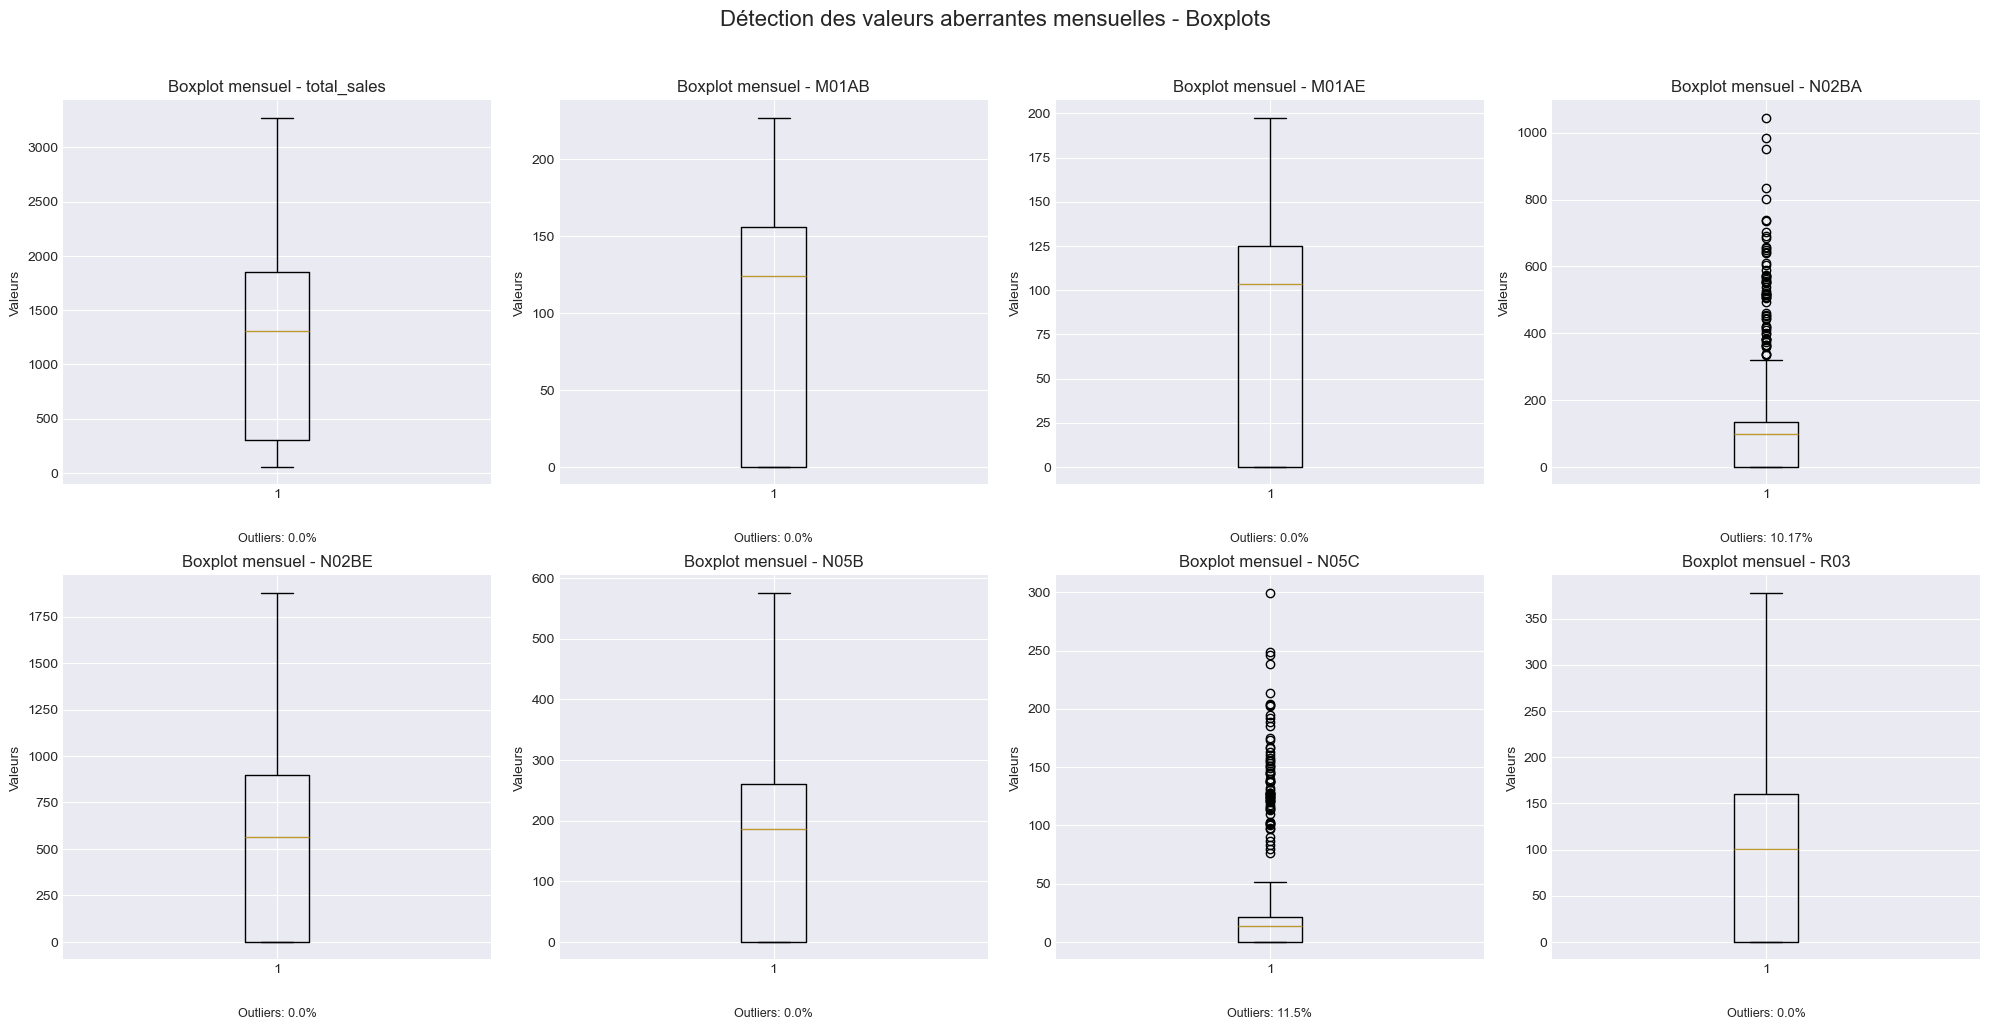


6. ANALYSE DE LA DISTRIBUTION MENSUELLE
----------------------------------------


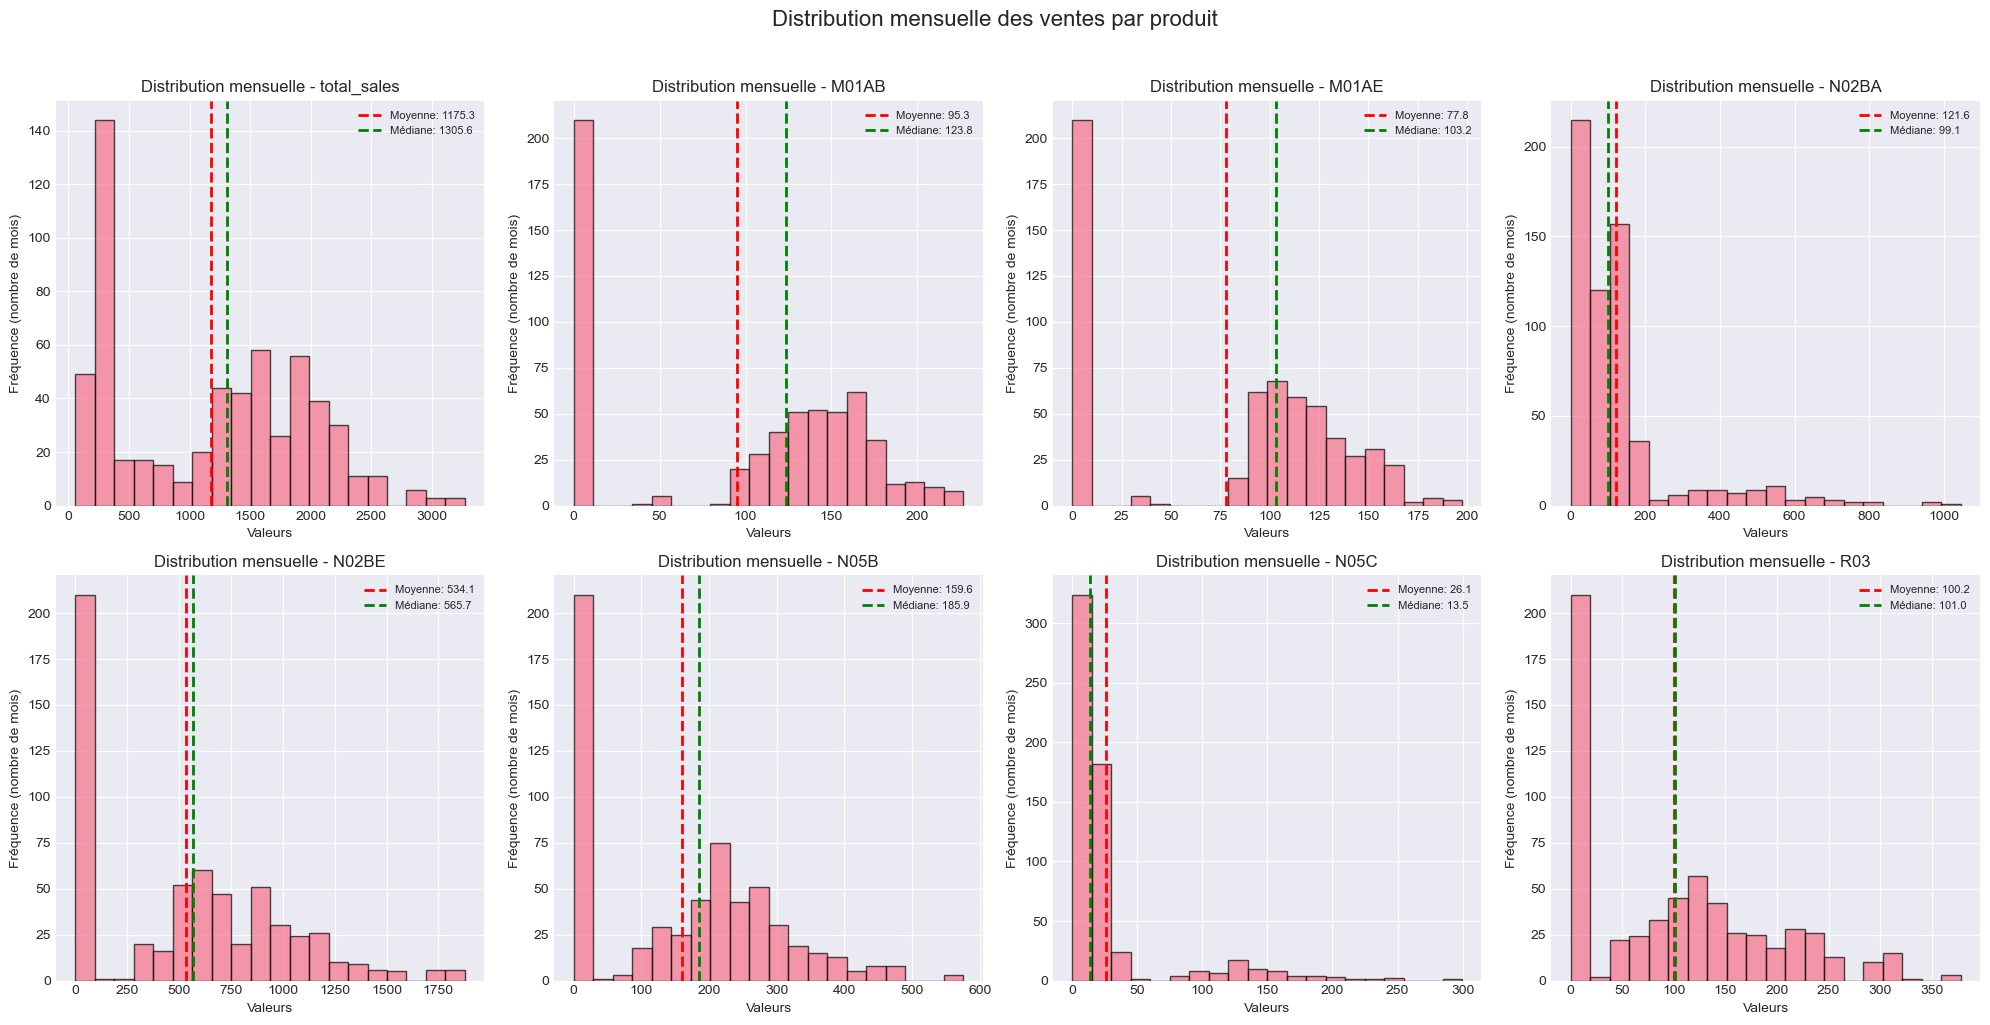


7. ANALYSE DE LA CORRÉLATION MENSUELLE
----------------------------------------


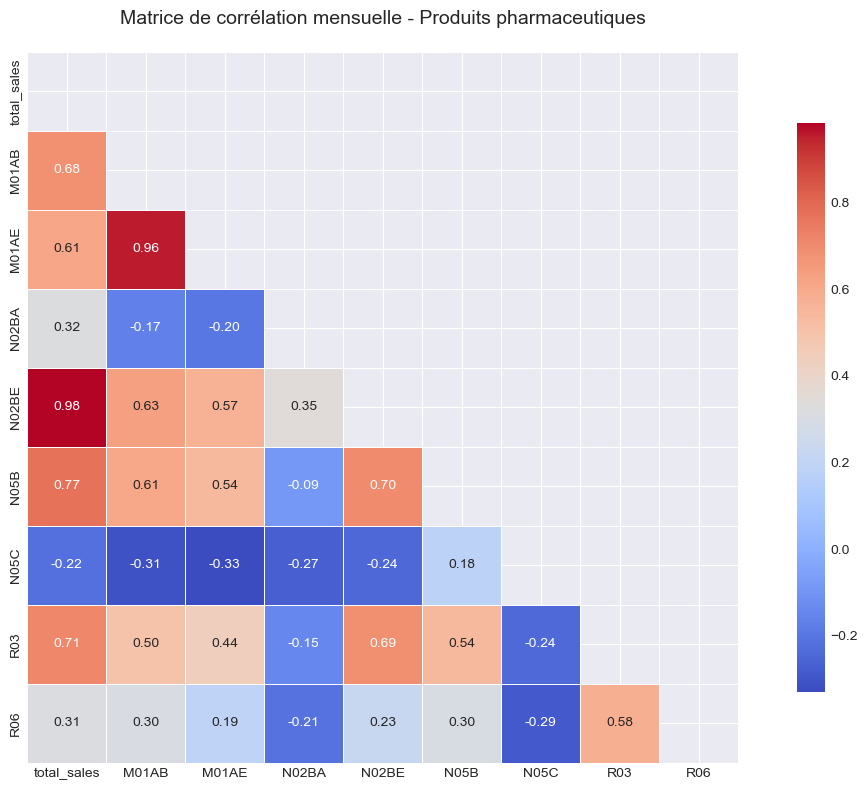


▶ Corrélations mensuelles les plus fortes (> 0.8 ou < -0.8):
  Produit 1 Produit 2  Corrélation
total_sales     N02BE        0.984
      M01AB     M01AE        0.956

8. ANALYSE TEMPORELLE MENSUELLE
----------------------------------------


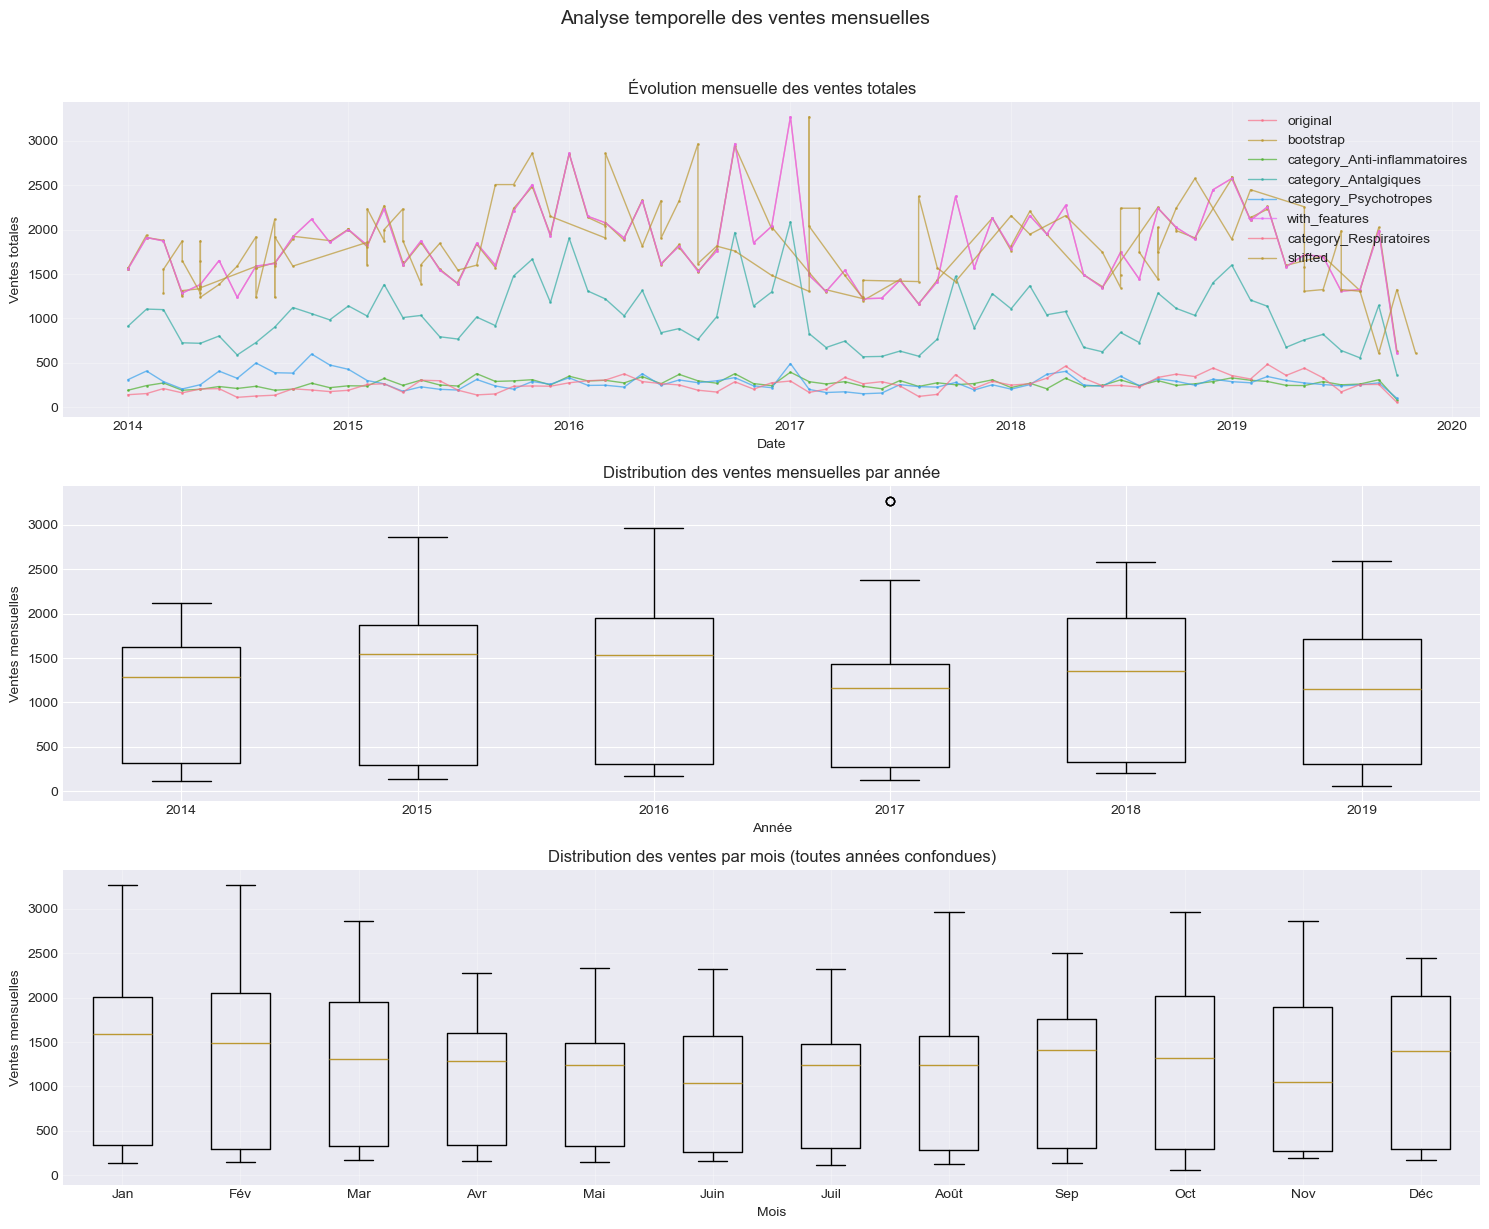


9. ANALYSE PAR SOURCE DE DONNÉES
----------------------------------------
                              total_sales_count  total_sales_mean  total_sales_std  total_sales_min  total_sales_max
source                                                                                                              
bootstrap                                   100           1783.00           393.04           637.01          2944.89
category_Antalgiques                         70           1016.82           345.07           367.30          2089.22
category_Anti-inflammatoires                 70            268.65            50.98            85.11           394.93
category_Psychotropes                        70            284.22            88.36           102.00           599.00
category_Respiratoires                       70            253.10            87.71            55.13           484.00
original                                     70           1822.79           453.49           609.54       

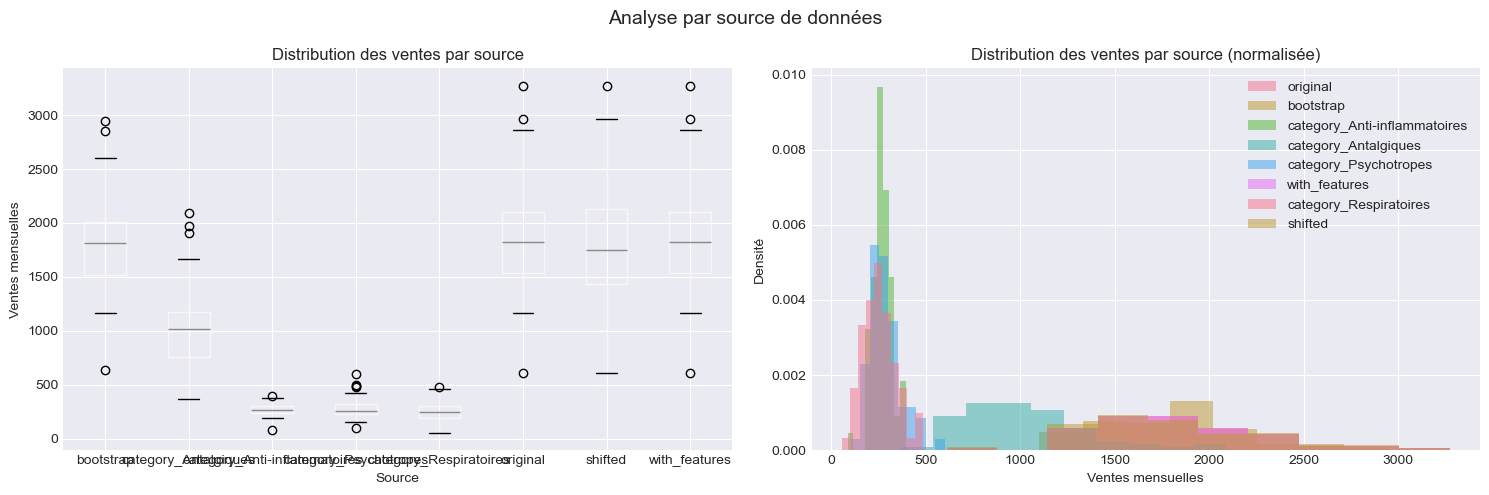


10. ANALYSE DE LA SAISONNALITÉ
----------------------------------------


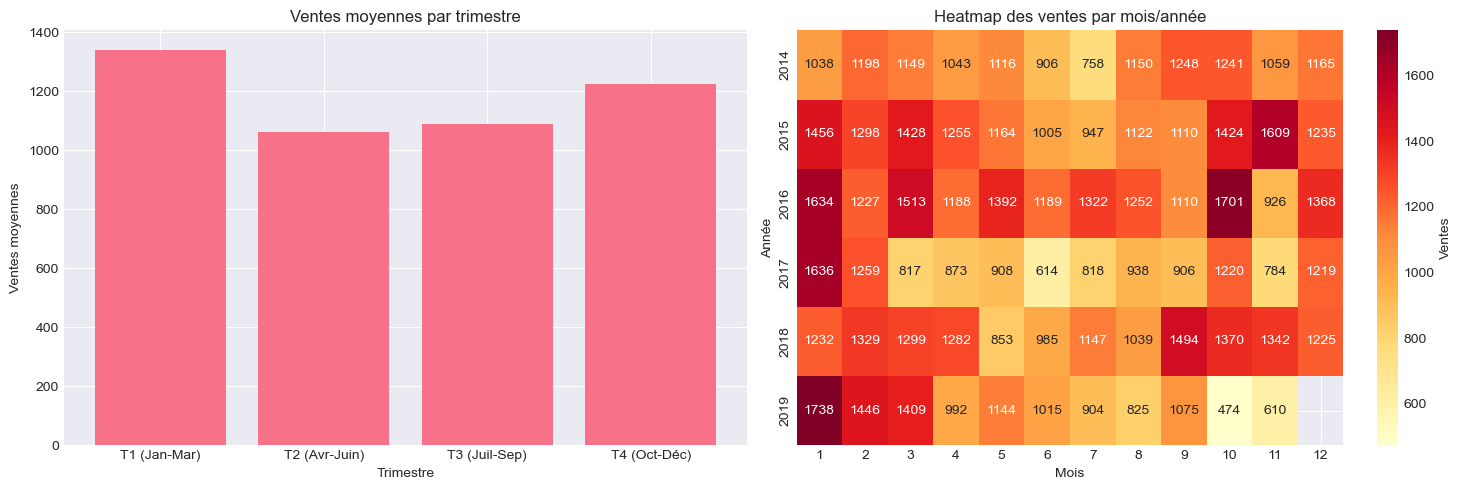


11. RÉSUMÉ DE LA QUALITÉ DES DONNÉES MENSUELLES
----------------------------------------

▶ POINTS À VÉRIFIER:

   ✅ Aucune valeur manquante dans les données mensuelles
   ✅ Aucune ligne dupliquée
   ⚠️  Produits avec >5% d'outliers mensuels: N02BA, N05C
   ✅ Série mensuelle complète et continue

▶ Statistiques clés des ventes mensuelles:
   - Ventes mensuelles moyennes: 1,175.35
   - Ventes mensuelles médianes: 1,305.56
   - Écart-type: 789.32
   - Coefficient de variation: 67.2%
   - Mois avec ventes max: 2017-01 (3,271.98)
   - Mois avec ventes min: 2019-10 (55.13)

ANALYSE MENSUELLE TERMINÉE


In [24]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration pour les visualisations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("ANALYSE EXPLORATOIRE DES DONNÉES MENSUELLES AUGMENTÉES - PRÉTRAITEMENT")
print("="*80)

# 1. CHARGEMENT DES DONNÉES MENSUELLES AUGMENTÉES
# ================================================
print("\n1. CHARGEMENT DES DONNÉES MENSUELLES AUGMENTÉES")
print("-" * 40)

try:
    # Essayer d'abord le fichier augmenté
    df = pd.read_excel('hcp_sales_monthly_augmented.xlsx')
    print(f"✅ Fichier mensuel AUGMENTÉ chargé avec succès")
except FileNotFoundError:
    try:
        # Sinon, prendre le fichier original
        df = pd.read_excel('hcp_sales_monthly_final.xlsx')
        print(f"⚠️  Fichier augmenté non trouvé, utilisation du fichier original")
    except FileNotFoundError:
        print("❌ Aucun fichier trouvé. Veuillez d'abord exécuter le code de fusion.")
        exit()

print(f"   - Nombre de lignes (mois): {df.shape[0]:,}")
print(f"   - Nombre de colonnes: {df.shape[1]}")
print(f"   - Période couverte: de {df['date'].min()} à {df['date'].max()}")

# S'assurer que la colonne date est au bon format
df['date'] = pd.to_datetime(df['date'])

# Identifier les colonnes de ventes
sales_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
# Ne garder que les colonnes qui existent vraiment
sales_columns = [col for col in sales_columns if col in df.columns]

# Créer total_sales si nécessaire
if 'total_sales' not in df.columns and len(sales_columns) > 0:
    df['total_sales'] = df[sales_columns].sum(axis=1)

# Ajouter les colonnes temporelles si elles n'existent pas
if 'year' not in df.columns:
    df['year'] = df['date'].dt.year
if 'month' not in df.columns:
    df['month'] = df['date'].dt.month
if 'quarter' not in df.columns:
    df['quarter'] = df['date'].dt.quarter

print(f"\n✅ Données préparées: {df.shape[0]} lignes, {df.shape[1]} colonnes")
if 'source' in df.columns:
    print(f"   - Sources de données: {df['source'].nunique()} types")
    print(df['source'].value_counts().to_string())

# 2. APERÇU GÉNÉRAL DES DONNÉES MENSUELLES
# =========================================
print("\n2. APERÇU GÉNÉRAL DES DONNÉES MENSUELLES")
print("-" * 40)

print("\n▶ Les 12 premiers mois (une année complète):")
print(df.head(12).to_string())

print("\n▶ Les 12 derniers mois:")
print(df.tail(12).to_string())

print("\n▶ Informations générales sur le DataFrame mensuel:")
print(df.info())

print("\n▶ Statistiques descriptives des ventes mensuelles:")
print(df.describe(include='all').round(2))

# 3. ANALYSE DES VALEURS MANQUANTES
# ==================================
print("\n3. ANALYSE DES VALEURS MANQUANTES")
print("-" * 40)

# Calcul des valeurs manquantes
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

# Créer un DataFrame pour une meilleure visualisation
missing_df = pd.DataFrame({
    'Colonne': missing_values.index,
    'Valeurs manquantes': missing_values.values,
    'Pourcentage (%)': missing_percentage.values
})
missing_df = missing_df[missing_df['Valeurs manquantes'] > 0].sort_values('Valeurs manquantes', ascending=False)

print(f"\n▶ Nombre total de cellules: {df.size:,}")
print(f"▶ Nombre total de valeurs manquantes: {df.isnull().sum().sum():,}")
print(f"▶ Pourcentage global de valeurs manquantes: {(df.isnull().sum().sum() / df.size * 100):.2f}%")

if len(missing_df) > 0:
    print("\n▶ Détail par colonne:")
    print(missing_df.to_string(index=False))
    
    # Visualisation des valeurs manquantes
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Graphique en barres
    axes[0].barh(missing_df['Colonne'], missing_df['Valeurs manquantes'])
    axes[0].set_xlabel('Nombre de valeurs manquantes')
    axes[0].set_title('Valeurs manquantes par colonne')
    
    # Heatmap des valeurs manquantes
    sns.heatmap(df[missing_df['Colonne']].isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=axes[1])
    axes[1].set_title('Pattern des valeurs manquantes')
    axes[1].set_xlabel('Colonnes')
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ Aucune valeur manquante détectée dans les données mensuelles !")

# 4. ANALYSE DES DOUBLONS
# =======================
print("\n4. ANALYSE DES DOUBLONS")
print("-" * 40)

# Vérifier les doublons exacts
duplicates_exact = df.duplicated().sum()
print(f"▶ Lignes exactement dupliquées: {duplicates_exact} ({duplicates_exact/len(df)*100:.2f}%)")

# Vérifier les doublons basés sur la date
if 'date' in df.columns:
    # Convertir en string pour éviter les problèmes de timezone
    date_strings = df['date'].dt.strftime('%Y-%m-%d')
    duplicates_date = date_strings.duplicated().sum()
    print(f"▶ Dates dupliquées: {duplicates_date} ({duplicates_date/len(df)*100:.2f}%)")
    
    if duplicates_date > 0:
        print("\n   Exemples de dates dupliquées (avec sources):")
        dup_dates = date_strings[date_strings.duplicated(keep=False)]
        dup_sample = df[date_strings.isin(dup_dates)].sort_values('date').head(10)
        if 'source' in dup_sample.columns:
            print(dup_sample[['date', 'source', 'total_sales']].to_string())
        else:
            print(dup_sample[['date', 'total_sales']].to_string())

# 5. ANALYSE DES VALEURS ABERRANTES (OUTLIERS)
# =============================================
print("\n5. ANALYSE DES VALEURS ABERRANTES (OUTLIERS) MENSUELLES")
print("-" * 40)

# Identifier les colonnes numériques (exclure les colonnes de date et temporelles)
exclude_cols = ['date', 'year', 'month', 'quarter', 'source', 'bootstrap_id', 'shift', 'source_detail', 'unique_id']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in exclude_cols and col in sales_columns + ['total_sales']]

print(f"▶ Colonnes numériques analysées: {', '.join(numeric_cols)}")

# Créer un DataFrame pour stocker les statistiques des outliers
outlier_stats = []

for col in numeric_cols:
    if col in df.columns and df[col].notna().sum() > 0:
        # Méthode IQR (Interquartile Range)
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col].count()
        pct_outliers_iqr = (outliers_iqr / len(df)) * 100
        
        # Méthode Z-score
        col_clean = df[col].dropna()
        if len(col_clean) > 1:
            z_scores = np.abs(stats.zscore(col_clean))
            outliers_zscore = (z_scores > 3).sum()
            pct_outliers_zscore = (outliers_zscore / len(df)) * 100
        else:
            outliers_zscore = 0
            pct_outliers_zscore = 0
        
        outlier_stats.append({
            'Colonne': col,
            'Min': df[col].min(),
            'Max': df[col].max(),
            'Moyenne': df[col].mean(),
            'Médiane': df[col].median(),
            'Écart-type': df[col].std(),
            'Outliers (IQR)': outliers_iqr,
            '% Outliers (IQR)': round(pct_outliers_iqr, 2),
            'Outliers (Z-score)': outliers_zscore,
            '% Outliers (Z-score)': round(pct_outliers_zscore, 2)
        })

if outlier_stats:
    outlier_df = pd.DataFrame(outlier_stats)
    print("\n▶ Statistiques des outliers par colonne:")
    print(outlier_df.to_string(index=False))

    # Visualisation des outliers avec des boxplots
    n_cols = min(len(numeric_cols), 8)
    n_rows = (n_cols + 3) // 4
    fig, axes = plt.subplots(n_rows, min(4, n_cols), figsize=(20, 5*n_rows))
    if n_rows == 1:
        axes = axes.flatten() if n_cols > 1 else [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(numeric_cols[:8]):
        if i < len(axes):
            axes[i].boxplot(df[col].dropna())
            axes[i].set_title(f'Boxplot mensuel - {col}')
            axes[i].set_ylabel('Valeurs')
            
            # Ajouter les statistiques
            stats_text = f"Outliers: {outlier_df[outlier_df['Colonne']==col]['% Outliers (IQR)'].values[0]}%"
            axes[i].text(0.5, -0.15, stats_text, transform=axes[i].transAxes, ha='center', fontsize=9)

    # Cacher les sous-graphiques inutilisés
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Détection des valeurs aberrantes mensuelles - Boxplots', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# 6. ANALYSE DE LA DISTRIBUTION DES DONNÉES MENSUELLES
# ====================================================
print("\n6. ANALYSE DE LA DISTRIBUTION MENSUELLE")
print("-" * 40)

if numeric_cols:
    n_cols = min(len(numeric_cols), 8)
    n_rows = (n_cols + 3) // 4
    fig, axes = plt.subplots(n_rows, min(4, n_cols), figsize=(20, 5*n_rows))
    if n_rows == 1:
        axes = axes.flatten() if n_cols > 1 else [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(numeric_cols[:8]):
        if i < len(axes):
            axes[i].hist(df[col].dropna(), bins=20, edgecolor='black', alpha=0.7)
            axes[i].set_title(f'Distribution mensuelle - {col}')
            axes[i].set_xlabel('Valeurs')
            axes[i].set_ylabel('Fréquence (nombre de mois)')
            
            # Ajouter des lignes pour la moyenne et la médiane
            mean_val = df[col].mean()
            median_val = df[col].median()
            axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Moyenne: {mean_val:.1f}')
            axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Médiane: {median_val:.1f}')
            axes[i].legend(fontsize=8)

    # Cacher les sous-graphiques inutilisés
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Distribution mensuelle des ventes par produit', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# 7. ANALYSE DE LA CORRÉLATION MENSUELLE
# ======================================
print("\n7. ANALYSE DE LA CORRÉLATION MENSUELLE")
print("-" * 40)

if len(numeric_cols) > 1:
    # Matrice de corrélation
    corr_matrix = df[numeric_cols].corr()
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Heatmap
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
                square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title('Matrice de corrélation mensuelle - Produits pharmaceutiques', fontsize=14, pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Trouver les corrélations les plus fortes
    print("\n▶ Corrélations mensuelles les plus fortes (> 0.8 ou < -0.8):")
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > 0.8:
                corr_pairs.append({
                    'Produit 1': corr_matrix.columns[i],
                    'Produit 2': corr_matrix.columns[j],
                    'Corrélation': round(corr_value, 3)
                })
    
    if corr_pairs:
        corr_df = pd.DataFrame(corr_pairs).sort_values('Corrélation', ascending=False)
        print(corr_df.to_string(index=False))
    else:
        print("   Aucune corrélation très forte détectée au niveau mensuel.")

# 8. ANALYSE TEMPORELLE MENSUELLE
# ===============================
print("\n8. ANALYSE TEMPORELLE MENSUELLE")
print("-" * 40)

if 'date' in df.columns and 'total_sales' in df.columns:
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    
    # Série temporelle complète (avec couleur par source si disponible)
    if 'source' in df.columns:
        for source in df['source'].unique():
            source_data = df[df['source'] == source]
            axes[0].plot(source_data['date'], source_data['total_sales'], 
                        marker='.', linestyle='-', linewidth=1, markersize=2, 
                        label=source, alpha=0.7)
        axes[0].legend()
    else:
        axes[0].plot(df['date'], df['total_sales'], marker='o', linestyle='-', markersize=4)
    
    axes[0].set_title('Évolution mensuelle des ventes totales', fontsize=12)
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Ventes totales')
    axes[0].grid(True, alpha=0.3)
    
    # Ventes par année (boxplot)
    if 'year' in df.columns:
        # Grouper par année pour le boxplot
        years = sorted(df['year'].unique())
        data_by_year = [df[df['year'] == year]['total_sales'].values for year in years]
        axes[1].boxplot(data_by_year, labels=years)
        axes[1].set_title('Distribution des ventes mensuelles par année')
        axes[1].set_xlabel('Année')
        axes[1].set_ylabel('Ventes mensuelles')
    
    # Ventes par mois (saisonnalité)
    if 'month' in df.columns:
        monthly_data = [df[df['month'] == m]['total_sales'].values for m in range(1, 13)]
        axes[2].boxplot(monthly_data, labels=['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 
                                              'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc'])
        axes[2].set_title('Distribution des ventes par mois (toutes années confondues)')
        axes[2].set_xlabel('Mois')
        axes[2].set_ylabel('Ventes mensuelles')
        axes[2].grid(True, alpha=0.3)
    
    plt.suptitle('Analyse temporelle des ventes mensuelles', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# 9. ANALYSE PAR SOURCE (si disponible)
# =====================================
print("\n9. ANALYSE PAR SOURCE DE DONNÉES")
print("-" * 40)

if 'source' in df.columns:
    source_stats = df.groupby('source').agg({
        'total_sales': ['count', 'mean', 'std', 'min', 'max']
    }).round(2)
    source_stats.columns = ['_'.join(col).strip() for col in source_stats.columns.values]
    print(source_stats.to_string())
    
    # Visualisation par source
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Boxplot par source
    df.boxplot(column='total_sales', by='source', ax=axes[0])
    axes[0].set_title('Distribution des ventes par source')
    axes[0].set_xlabel('Source')
    axes[0].set_ylabel('Ventes mensuelles')
    
    # Histogramme par source
    for source in df['source'].unique():
        source_data = df[df['source'] == source]['total_sales']
        axes[1].hist(source_data, bins=10, alpha=0.5, label=source, density=True)
    axes[1].set_title('Distribution des ventes par source (normalisée)')
    axes[1].set_xlabel('Ventes mensuelles')
    axes[1].set_ylabel('Densité')
    axes[1].legend()
    
    plt.suptitle('Analyse par source de données', fontsize=14)
    plt.tight_layout()
    plt.show()

# 10. ANALYSE DE LA SAISONNALITÉ
# ==============================
print("\n10. ANALYSE DE LA SAISONNALITÉ")
print("-" * 40)

if 'quarter' in df.columns and 'total_sales' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Ventes par trimestre
    quarterly_sales = df.groupby('quarter')['total_sales'].mean()
    quarters = ['T1 (Jan-Mar)', 'T2 (Avr-Juin)', 'T3 (Juil-Sep)', 'T4 (Oct-Déc)']
    axes[0].bar(quarters, quarterly_sales.values)
    axes[0].set_title('Ventes moyennes par trimestre')
    axes[0].set_xlabel('Trimestre')
    axes[0].set_ylabel('Ventes moyennes')
    
    # Heatmap mois-année
    if 'year' in df.columns and 'month' in df.columns:
        pivot_table = df.pivot_table(values='total_sales', index='year', columns='month', aggfunc='mean')
        sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Ventes'})
        axes[1].set_title('Heatmap des ventes par mois/année')
        axes[1].set_xlabel('Mois')
        axes[1].set_ylabel('Année')
    
    plt.tight_layout()
    plt.show()

# 11. RÉSUMÉ DE LA QUALITÉ DES DONNÉES MENSUELLES
# ===============================================
print("\n11. RÉSUMÉ DE LA QUALITÉ DES DONNÉES MENSUELLES")
print("-" * 40)

print("""
▶ POINTS À VÉRIFIER:
""")

# Vérification 1: Valeurs manquantes
if missing_values.sum() > 0:
    print(f"   ⚠️  {missing_values.sum():,} valeurs manquantes détectées")
    print(f"       → Les colonnes concernées: {', '.join(missing_df['Colonne'].tolist())}")
else:
    print("   ✅ Aucune valeur manquante dans les données mensuelles")

# Vérification 2: Doublons
if duplicates_exact > 0:
    print(f"   ⚠️  {duplicates_exact} lignes dupliquées")
else:
    print("   ✅ Aucune ligne dupliquée")

# Vérification 3: Outliers
if 'outlier_df' in locals() and len(outlier_df) > 0:
    cols_with_high_outliers = outlier_df[outlier_df['% Outliers (IQR)'] > 5]['Colonne'].tolist()
    if cols_with_high_outliers:
        print(f"   ⚠️  Produits avec >5% d'outliers mensuels: {', '.join(cols_with_high_outliers)}")
    else:
        print("   ✅ Pas de problème majeur d'outliers mensuels")

# Vérification 4: Continuité de la série temporelle
if 'date' in df.columns:
    date_min = df['date'].min()
    date_max = df['date'].max()
    
    # Créer une série de mois attendus
    expected_months = pd.date_range(start=date_min, end=date_max, freq='MS')
    actual_dates = pd.to_datetime(df['date'].dt.strftime('%Y-%m-01'))
    missing_months = set(expected_months) - set(actual_dates)
    
    if missing_months:
        print(f"   ⚠️  {len(missing_months)} mois manquants dans la série temporelle")
        print(f"       → Exemple: {sorted(list(missing_months))[:5]}")
    else:
        print("   ✅ Série mensuelle complète et continue")

# Statistiques clés
print(f"\n▶ Statistiques clés des ventes mensuelles:")
print(f"   - Ventes mensuelles moyennes: {df['total_sales'].mean():,.2f}")
print(f"   - Ventes mensuelles médianes: {df['total_sales'].median():,.2f}")
print(f"   - Écart-type: {df['total_sales'].std():,.2f}")
print(f"   - Coefficient de variation: {(df['total_sales'].std() / df['total_sales'].mean() * 100):.1f}%")
print(f"   - Mois avec ventes max: {df.loc[df['total_sales'].idxmax(), 'date'].strftime('%Y-%m')} ({df['total_sales'].max():,.2f})")
print(f"   - Mois avec ventes min: {df.loc[df['total_sales'].idxmin(), 'date'].strftime('%Y-%m')} ({df['total_sales'].min():,.2f})")

print("\n" + "="*80)
print("ANALYSE MENSUELLE TERMINÉE")
print("="*80)

# Modeling

## DSO1

## DSO2

## DSO3

## DSO4

# Deployment